# Quantitative Trading With Machine Learning

### UE24CS352A — Machine Learning Mini Project

**Problem:** Quantitative Trading With Machine Learning

This project investigates whether machine learning models can predict
future Volkswagen AG (VWAGY) stock returns and use those predictions
to construct a quantitative trading strategy.

Two approaches are evaluated:

1. **VWAGY-only baseline**
   - Uses Volkswagen's historical price, return, volatility,
     moving-average, and volume information.

2. **Supply-chain enhanced model**
   - Extends the baseline with lagged returns from selected publicly
     traded companies used as supply-chain proxy variables.

The models evaluated are:

- Elastic Net
- Decision Tree
- XGBoost
- LightGBM

The evaluation follows a chronological time-series methodology to avoid
using future information when training the models.

The final trading strategy is evaluated on an unseen test period and
compared against a simple VWAGY Buy & Hold strategy.

## 1. Objective

The objective of this project is to determine whether historical market
information and supply-chain information can provide useful signals for
predicting future VWAGY returns.

The project focuses on the following questions:

- Can machine learning models predict next-day VWAGY returns?
- Which model performs best among Elastic Net, Decision Tree, XGBoost,
  and LightGBM?
- Does adding supply-chain proxy information improve the predictive
  modelling framework?
- Can the predictions be converted into a trading strategy?
- How does the resulting strategy compare with simply holding VWAGY?

The evaluation uses chronological train, validation, and final test
periods rather than randomly shuffled observations.

In [1]:
#Importing Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset

Historical VWAGY market data is obtained using Yahoo Finance through
the `yfinance` Python library.

The study period is:

**January 2015 – December 2025**

The baseline dataset uses:

- Open
- High
- Low
- Close
- Volume

The modelling features are derived only from information available up
to each trading day.

In [2]:
# Downloading VWAGY Data

VW_TICKER = "VWAGY"

START_DATE = "2015-01-01"
END_DATE = "2025-12-31"

raw_vw = yf.download(
    VW_TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

# Handle possible MultiIndex columns from yfinance
if isinstance(raw_vw.columns, pd.MultiIndex):
    vw_data = raw_vw.xs(
        VW_TICKER,
        axis=1,
        level=1
    ).copy()
else:
    vw_data = raw_vw.copy()

vw_data = vw_data[
    ["Open", "High", "Low", "Close", "Volume"]
]

print("VWAGY dataset downloaded.")
print(f"Shape: {vw_data.shape}")
print(f"Start: {vw_data.index.min().date()}")
print(f"End:   {vw_data.index.max().date()}")

display(vw_data.head())

VWAGY dataset downloaded.
Shape: (2765, 5)
Start: 2015-01-02
End:   2025-12-30


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,13.242967,13.246046,13.085899,13.161353,199400
2015-01-05,12.790238,12.790238,12.627011,12.663968,95200
2015-01-06,12.817957,12.965785,12.713245,12.802558,443800
2015-01-07,12.808720,12.907272,12.694769,12.870316,340400
2015-01-08,12.925750,13.255284,12.898032,13.196768,597400


In [4]:
# Data Quality Check

print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

print("\nDataset shape:")
print(vw_data.shape)

print("\nMissing values:")
display(vw_data.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:")
print(vw_data.index.duplicated().sum())

print("\nData types:")
display(vw_data.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(vw_data.describe())

DATA QUALITY CHECK

Dataset shape:
(2765, 5)

Missing values:


,Missing Values
Price,
Open,0
High,0
Low,0
Close,0
Volume,0



Duplicate rows:
0

Data types:


,Data Type
Price,
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64



Summary statistics:


Price,Open,High,Low,Close,Volume
count,2765.000000,2765.000000,2765.000000,2765.000000,2.765000e+03
mean,12.099383,12.201308,11.993121,12.101131,3.618954e+05
std,3.514512,3.571719,3.470178,3.523405,7.342325e+05
min,7.023391,7.123483,6.743454,6.794349,3.100000e+03
25%,9.826700,9.901426,9.761606,9.818274,1.368000e+05
50%,11.040814,11.107614,10.951626,11.041020,2.304000e+05
75%,13.173844,13.281469,13.063100,13.181371,3.860000e+05
max,27.665642,32.015922,24.774222,27.816790,1.767300e+07


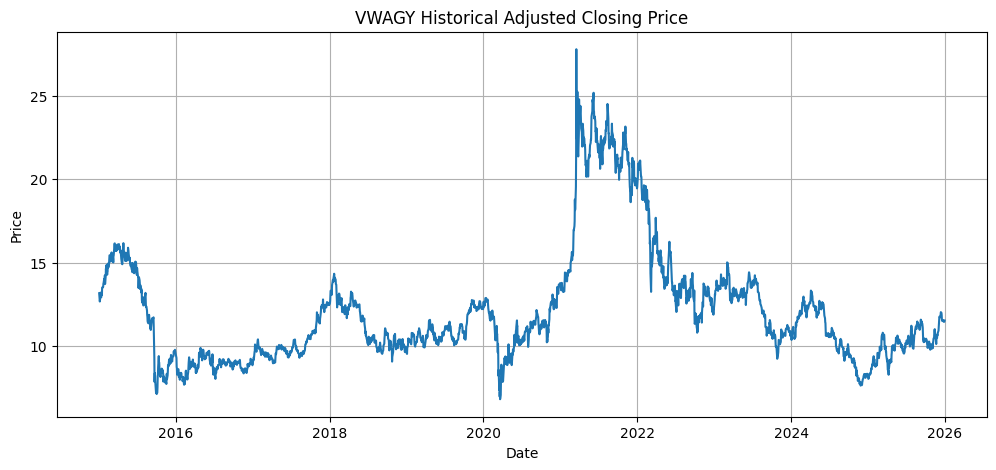

In [5]:
# VWAGY Price History

plt.figure(figsize=(12, 5))

plt.plot(
    vw_data.index,
    vw_data["Close"]
)

plt.title("VWAGY Historical Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.show()

## 3. VWAGY Baseline Feature Engineering

The baseline model uses technical and market-derived variables calculated
from VWAGY historical data.

The features include:

### Return features
- 1-day return
- 5-day return
- 10-day return
- 20-day return

### Moving-average features
- 5-day moving average ratio
- 20-day moving average ratio
- 50-day moving average ratio

### Volatility
- 5-day rolling volatility
- 20-day rolling volatility

### Volume
- Daily volume change
- 20-day volume moving average
- Volume ratio

These features are calculated using current and historical information
only.

In [6]:
# Baseline Feature Engineering

baseline = vw_data.copy()

close = baseline["Close"]
volume = baseline["Volume"]

# Return Feature

baseline["Return_1D"] = close.pct_change(1)
baseline["Return_5D"] = close.pct_change(5)
baseline["Return_10D"] = close.pct_change(10)
baseline["Return_20D"] = close.pct_change(20)

# Moving Averages

baseline["MA_5"] = close.rolling(5).mean()
baseline["MA_10"] = close.rolling(10).mean()
baseline["MA_20"] = close.rolling(20).mean()
baseline["MA_50"] = close.rolling(50).mean()

baseline["Price_MA5_Ratio"] = (
    close / baseline["MA_5"] - 1
)

baseline["Price_MA20_Ratio"] = (
    close / baseline["MA_20"] - 1
)

baseline["Price_MA50_Ratio"] = (
    close / baseline["MA_50"] - 1
)


# Volatility

baseline["Volatility_5D"] = (
    baseline["Return_1D"]
    .rolling(5)
    .std()
)

baseline["Volatility_20D"] = (
    baseline["Return_1D"]
    .rolling(20)
    .std()
)


# Volume features

baseline["Volume_Change"] = (
    volume.pct_change()
)

baseline["Volume_MA20"] = (
    volume.rolling(20).mean()
)

baseline["Volume_Ratio"] = (
    volume / baseline["Volume_MA20"]
)

# Next-day target

baseline["Target_Return"] = (
    close.shift(-1) / close - 1
)

# Remove rows created by rolling calculations
baseline = baseline.replace(
    [np.inf, -np.inf],
    np.nan
)

baseline = baseline.dropna()

print("Baseline feature dataset created.")
print(f"Shape: {baseline.shape}")

display(
    baseline[
        [
            "Return_1D",
            "Return_5D",
            "Return_20D",
            "Price_MA20_Ratio",
            "Volatility_20D",
            "Volume_Ratio",
            "Target_Return"
        ]
    ].head()
)

Baseline feature dataset created.
Shape: (2715, 22)


Price,Return_1D,Return_5D,Return_20D,Price_MA20_Ratio,Volatility_20D,Volume_Ratio,Target_Return
Date,,,,,,,
2015-03-16,0.033715,0.059192,0.097781,0.055174,0.015473,2.180264,0.000381
2015-03-17,0.000381,0.076118,0.095218,0.050755,0.015498,1.019819,-0.017731
2015-03-18,-0.017731,0.028651,0.060519,0.029093,0.016090,1.446898,-0.008928
2015-03-19,-0.008928,0.018755,0.034336,0.018181,0.015993,0.468142,0.020368
2015-03-20,0.020368,0.027208,0.039505,0.036872,0.016257,0.994381,-0.020921


In [7]:
# Features & Targets

BASELINE_FEATURES = [
    "Return_1D",
    "Return_5D",
    "Return_10D",
    "Return_20D",

    "Price_MA5_Ratio",
    "Price_MA20_Ratio",
    "Price_MA50_Ratio",

    "Volatility_5D",
    "Volatility_20D",

    "Volume_Change",
    "Volume_MA20",
    "Volume_Ratio"
]

X_baseline = baseline[
    BASELINE_FEATURES
].copy()

y_baseline = baseline[
    "Target_Return"
].copy()

print(f"Number of baseline features: {X_baseline.shape[1]}")
print(f"Number of observations: {len(X_baseline)}")

display(
    X_baseline.head()
)

Number of baseline features: 12
Number of observations: 2715


Price,Return_1D,Return_5D,Return_10D,Return_20D,Price_MA5_Ratio,Price_MA20_Ratio,Price_MA50_Ratio,Volatility_5D,Volatility_20D,Volume_Change,Volume_MA20,Volume_Ratio
Date,,,,,,,,,,,,
2015-03-16,0.033715,0.059192,0.034530,0.097781,0.039886,0.055174,0.122070,0.019939,0.015473,1.827515,252630.0,2.180264
2015-03-17,0.000381,0.076118,0.063894,0.095218,0.025195,0.050755,0.117850,0.015299,0.015498,-0.518882,259850.0,1.019819
2015-03-18,-0.017731,0.028651,0.051000,0.060519,0.001399,0.029093,0.093183,0.018884,0.016090,0.510943,276730.0,1.446898
2015-03-19,-0.008928,0.018755,0.034860,0.034336,-0.011155,0.018181,0.079077,0.019993,0.015993,-0.678322,275130.0,0.468142
2015-03-20,0.020368,0.027208,0.061748,0.039505,0.003621,0.036872,0.096278,0.021161,0.016257,1.170807,281180.0,0.994381


In [9]:
# CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT

n_baseline = len(X_baseline)

train_end = int(n_baseline * 0.60)
validation_end = int(n_baseline * 0.80)

X_train_base = X_baseline.iloc[
    :train_end
].copy()

y_train_base = y_baseline.iloc[
    :train_end
].copy()

X_val_base = X_baseline.iloc[
    train_end:validation_end
].copy()

y_val_base = y_baseline.iloc[
    train_end:validation_end
].copy()

X_test_base = X_baseline.iloc[
    validation_end:
].copy()

y_test_base = y_baseline.iloc[
    validation_end:
].copy()

print("=" * 60)
print("CHRONOLOGICAL DATA SPLIT")
print("=" * 60)

print(
    f"TRAIN      : "
    f"{X_train_base.index.min().date()} → "
    f"{X_train_base.index.max().date()} "
    f"({len(X_train_base)})"
)

print(
    f"VALIDATION : "
    f"{X_val_base.index.min().date()} → "
    f"{X_val_base.index.max().date()} "
    f"({len(X_val_base)})"
)

print(
    f"FINAL TEST : "
    f"{X_test_base.index.min().date()} → "
    f"{X_test_base.index.max().date()} "
    f"({len(X_test_base)})"
)

CHRONOLOGICAL DATA SPLIT
TRAIN      : 2015-03-16 → 2021-08-31 (1629)
VALIDATION : 2021-09-01 → 2023-10-27 (543)
FINAL TEST : 2023-10-30 → 2025-12-29 (543)


In [10]:
# ============================================================
# CELL 12 — FEATURE SCALING
# ============================================================

scaler_base = StandardScaler()

X_train_base_scaled = scaler_base.fit_transform(
    X_train_base
)

X_val_base_scaled = scaler_base.transform(
    X_val_base
)

X_test_base_scaled = scaler_base.transform(
    X_test_base
)

print("Feature scaling completed.")
print("Scaler fitted using training data only.")

Feature scaling completed.
Scaler fitted using training data only.


## 4. Baseline Machine Learning Models

Four regression models are evaluated:

### Elastic Net
A regularized linear model combining L1 and L2 penalties.
It provides a simple interpretable baseline.

### Decision Tree
A nonlinear tree-based model capable of learning feature interactions.

### XGBoost
A gradient-boosted decision-tree ensemble designed to model nonlinear
relationships effectively.

### LightGBM
A gradient-boosting framework based on efficient tree construction.

All models are trained chronologically using the training set and
evaluated first on the validation set.

In [11]:
# ============================================================
# CELL 14 — ELASTIC NET
# ============================================================

elastic_base = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=42
)

elastic_base.fit(
    X_train_base_scaled,
    y_train_base
)

elastic_val_pred = elastic_base.predict(
    X_val_base_scaled
)

print("Elastic Net trained.")

Elastic Net trained.


In [12]:
# ============================================================
# CELL 15 — DECISION TREE
# ============================================================

tree_base = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)

tree_base.fit(
    X_train_base,
    y_train_base
)

tree_val_pred = tree_base.predict(
    X_val_base
)

print("Decision Tree trained.")

Decision Tree trained.


In [13]:
# ============================================================
# CELL 16 — XGBOOST
# ============================================================

xgb_base = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_base.fit(
    X_train_base,
    y_train_base
)

xgb_val_pred = xgb_base.predict(
    X_val_base
)

print("XGBoost trained.")

XGBoost trained.


In [14]:
# ============================================================
# CELL 17 — LIGHTGBM
# ============================================================

lgb_base = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=20,
    subsample=0.8,
    colsample_bytree=0.8,
    verbosity=-1,
    random_state=42
)

lgb_base.fit(
    X_train_base,
    y_train_base
)

lgb_val_pred = lgb_base.predict(
    X_val_base
)

print("LightGBM trained.")

LightGBM trained.


In [15]:
# ============================================================
# CELL 18 — BASELINE MODEL COMPARISON
# ============================================================

baseline_predictions = {
    "Elastic Net": elastic_val_pred,
    "Decision Tree": tree_val_pred,
    "XGBoost": xgb_val_pred,
    "LightGBM": lgb_val_pred
}

baseline_results = []

for name, predictions in baseline_predictions.items():

    rmse = np.sqrt(
        mean_squared_error(
            y_val_base,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_val_base,
        predictions
    )

    r2 = r2_score(
        y_val_base,
        predictions
    )

    baseline_results.append({
        "Model": name,
        "Validation RMSE": rmse,
        "Validation MAE": mae,
        "Validation R2": r2
    })

baseline_results_df = pd.DataFrame(
    baseline_results
).sort_values(
    "Validation RMSE"
)

display(baseline_results_df)

baseline_best_model = (
    baseline_results_df.iloc[0]["Model"]
)

print(
    f"Best baseline model: "
    f"{baseline_best_model}"
)

,Model,Validation RMSE,Validation MAE,Validation R2
0,Elastic Net,0.024720,0.018272,-0.006324
1,Decision Tree,0.025514,0.018669,-0.072031
2,XGBoost,0.026169,0.019449,-0.127735
3,LightGBM,0.026195,0.019266,-0.130032


Best baseline model: Elastic Net


In [16]:
# ============================================================
# CELL 19 — BASELINE FINAL TEST EVALUATION
# ============================================================

# Evaluate all baseline models on the untouched test set.

baseline_test_models = {
    "Elastic Net": (
        elastic_base,
        X_test_base_scaled
    ),
    "Decision Tree": (
        tree_base,
        X_test_base
    ),
    "XGBoost": (
        xgb_base,
        X_test_base
    ),
    "LightGBM": (
        lgb_base,
        X_test_base
    )
}

baseline_test_results = []

for name, (model, features) in baseline_test_models.items():

    predictions = model.predict(
        features
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_base,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test_base,
        predictions
    )

    r2 = r2_score(
        y_test_base,
        predictions
    )

    baseline_test_results.append({
        "Model": name,
        "Test RMSE": rmse,
        "Test MAE": mae,
        "Test R2": r2
    })

baseline_test_results_df = pd.DataFrame(
    baseline_test_results
)

display(
    baseline_test_results_df.sort_values(
        "Test RMSE"
    )
)

,Model,Test RMSE,Test MAE,Test R2
0,Elastic Net,0.017868,0.013656,-0.001706
2,XGBoost,0.018113,0.013812,-0.029333
1,Decision Tree,0.018167,0.013821,-0.035461
3,LightGBM,0.018224,0.013968,-0.041989


## 5. Supply-Chain Enhanced Model

The baseline model uses only Volkswagen's own historical market data.

To investigate whether information from related companies can provide
additional predictive information, we construct a supply-chain enhanced
feature set.

This section is a scaled-down adaptation of the supply-chain approach
described in the reference quantitative-trading project.

For each selected supply-chain proxy, the previous 28 daily returns are
included as features. Volkswagen's own technical and momentum features
are retained as well.

### Supply-chain proxy universe

The following publicly traded companies are used as proxies:

- Continental (CON.DE)
- Infineon Technologies (IFX.DE)
- HELLA (HLE.DE)
- BASF (BAS.DE)
- BorgWarner (BWA)
- Magna International (MGA)
- Lear (LEA)
- Aptiv (APTV)
- TSMC (TSM) as an indirect semiconductor proxy

These are used as a practical proxy universe for this mini-project and
are NOT claimed to be the exact supplier list from the reference study.

The original reference methodology also included macroeconomic variables.
Those variables are not included here because the required proprietary
data source is not available in this implementation.

In [17]:
# ============================================================
# CELL 21 — SUPPLY-CHAIN PRICE DATA
# ============================================================

SUPPLY_CHAIN_TICKERS = [
    "CON.DE",
    "IFX.DE",
    "HLE.DE",
    "BAS.DE",
    "BWA",
    "MGA",
    "LEA",
    "APTV",
    "TSM"
]

ALL_SC_TICKERS = [
    VW_TICKER
] + SUPPLY_CHAIN_TICKERS

raw_sc = yf.download(
    ALL_SC_TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

# Extract Close prices
if isinstance(raw_sc.columns, pd.MultiIndex):
    sc_prices = raw_sc["Close"].copy()
else:
    sc_prices = raw_sc[["Close"]].copy()

# Remove completely missing columns
sc_prices = sc_prices.dropna(
    axis=1,
    how="all"
)

print("=" * 60)
print("SUPPLY-CHAIN PRICE DATA")
print("=" * 60)

print(
    f"Requested tickers: {len(ALL_SC_TICKERS)}"
)

print(
    f"Downloaded tickers: {len(sc_prices.columns)}"
)

print(
    "Downloaded:",
    list(sc_prices.columns)
)

display(sc_prices.head())

SUPPLY-CHAIN PRICE DATA
Requested tickers: 10
Downloaded tickers: 10
Downloaded: ['APTV', 'BAS.DE', 'BWA', 'CON.DE', 'HLE.DE', 'IFX.DE', 'LEA', 'MGA', 'TSM', 'VWAGY']


Ticker,APTV,BAS.DE,BWA,CON.DE,HLE.DE,IFX.DE,LEA,MGA,TSM,VWAGY
Date,,,,,,,,,,
2015-01-02,57.221512,38.040726,40.572895,76.184998,27.072557,7.753382,79.307022,38.853378,16.502058,13.161353
2015-01-05,54.722660,36.414074,39.401810,74.920776,25.635183,7.589401,76.706657,38.023880,16.102098,12.663968
2015-01-06,54.375805,36.403156,39.127571,74.455025,25.752043,7.396634,76.455544,37.201557,15.820642,12.802558
2015-01-07,54.809368,36.643326,40.046646,74.743347,26.020819,7.506538,77.630150,38.281319,16.050253,12.870316
2015-01-08,56.157326,38.138981,40.728539,77.249596,27.111513,7.752510,78.845299,39.007118,16.153938,13.196768


In [18]:
# ============================================================
# CELL 22 — SUPPLY-CHAIN DATA QUALITY
# ============================================================

missing_ratio = (
    sc_prices.isna().mean()
    .sort_values(ascending=False)
)

missing_table = pd.DataFrame({
    "Missing Fraction": missing_ratio,
    "Missing Percentage": missing_ratio * 100
})

display(missing_table)

# Retain stocks with <= 30% missing observations
valid_sc_tickers = missing_ratio[
    missing_ratio <= 0.30
].index.tolist()

sc_prices = sc_prices[
    valid_sc_tickers
].copy()

# Limited forward filling for short market-calendar gaps
sc_prices = sc_prices.ffill(
    limit=5
)

print(
    f"\nRetained {len(valid_sc_tickers)} tickers:"
)

print(valid_sc_tickers)

,Missing Fraction,Missing Percentage
Ticker,,
APTV,0.026066,2.606552
BWA,0.026066,2.606552
VWAGY,0.026066,2.606552
TSM,0.026066,2.606552
MGA,0.026066,2.606552
LEA,0.026066,2.606552
BAS.DE,0.015498,1.549841
IFX.DE,0.015498,1.549841
CON.DE,0.015498,1.549841



Retained 10 tickers:
['APTV', 'BWA', 'VWAGY', 'TSM', 'MGA', 'LEA', 'BAS.DE', 'IFX.DE', 'CON.DE', 'HLE.DE']


## 5.1 Supply-Chain Lagged Return Features

For every retained supply-chain proxy, we calculate its daily return and
include the previous 28 trading-day returns.

For example, for a company `CON.DE`:

- `CON.DE_Return_Lag_1`
- `CON.DE_Return_Lag_2`
- ...
- `CON.DE_Return_Lag_28`

These lagged variables allow the model to learn whether recent movements
in related companies contain information about subsequent VWAGY returns.

No future supply-chain information is used as a predictor.

In [19]:
# ============================================================
# CELL 24 — SUPPLY-CHAIN LAG FEATURES
# ============================================================

sc_returns = sc_prices.pct_change()

# Separate VWAGY from supply-chain proxies
supplier_returns = sc_returns.drop(
    columns=[VW_TICKER],
    errors="ignore"
)

supply_features = pd.DataFrame(
    index=sc_prices.index
)

for ticker in supplier_returns.columns:

    for lag in range(1, 29):

        supply_features[
            f"{ticker}_Return_Lag_{lag}"
        ] = supplier_returns[
            ticker
        ].shift(lag)

print(
    f"Supply-chain lag features created: "
    f"{supply_features.shape[1]}"
)

display(
    supply_features.head()
)

Supply-chain lag features created: 252


,APTV_Return_Lag_1,APTV_Return_Lag_2,APTV_Return_Lag_3,APTV_Return_Lag_4,APTV_Return_Lag_5,APTV_Return_Lag_6,APTV_Return_Lag_7,APTV_Return_Lag_8,APTV_Return_Lag_9,APTV_Return_Lag_10,...,HLE.DE_Return_Lag_19,HLE.DE_Return_Lag_20,HLE.DE_Return_Lag_21,HLE.DE_Return_Lag_22,HLE.DE_Return_Lag_23,HLE.DE_Return_Lag_24,HLE.DE_Return_Lag_25,HLE.DE_Return_Lag_26,HLE.DE_Return_Lag_27,HLE.DE_Return_Lag_28
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-06,-0.043670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,-0.006338,-0.043670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08,0.007973,-0.006338,-0.04367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# ============================================================
# CELL 25 — VWAGY FEATURES FOR ENHANCED MODEL
# ============================================================

vw_sc_close = sc_prices[VW_TICKER]

vw_sc_return = (
    vw_sc_close.pct_change()
)

vw_features = pd.DataFrame(
    index=sc_prices.index
)

# Returns
vw_features["VW_Return_1D"] = (
    vw_sc_return
)

vw_features["VW_Return_5D"] = (
    vw_sc_close.pct_change(5)
)

vw_features["VW_Return_10D"] = (
    vw_sc_close.pct_change(10)
)

vw_features["VW_Return_20D"] = (
    vw_sc_close.pct_change(20)
)

# Moving-average ratios
vw_features["VW_MA5_Ratio"] = (
    vw_sc_close /
    vw_sc_close.rolling(5).mean()
    - 1
)

vw_features["VW_MA20_Ratio"] = (
    vw_sc_close /
    vw_sc_close.rolling(20).mean()
    - 1
)

vw_features["VW_MA50_Ratio"] = (
    vw_sc_close /
    vw_sc_close.rolling(50).mean()
    - 1
)

# Volatility
vw_features["VW_Volatility_5D"] = (
    vw_sc_return.rolling(5).std()
)

vw_features["VW_Volatility_20D"] = (
    vw_sc_return.rolling(20).std()
)

# Longer-term momentum
vw_features["VW_Return_60D"] = (
    vw_sc_close.pct_change(60)
)

vw_features["VW_Momentum_20D"] = (
    vw_sc_close /
    vw_sc_close.shift(20)
    - 1
)

vw_features["VW_Momentum_60D"] = (
    vw_sc_close /
    vw_sc_close.shift(60)
    - 1
)

print(
    f"VWAGY features created: "
    f"{vw_features.shape[1]}"
)

display(vw_features.head())

VWAGY features created: 12


,VW_Return_1D,VW_Return_5D,VW_Return_10D,VW_Return_20D,VW_MA5_Ratio,VW_MA20_Ratio,VW_MA50_Ratio,VW_Volatility_5D,VW_Volatility_20D,VW_Return_60D,VW_Momentum_20D,VW_Momentum_60D
Date,,,,,,,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,-0.037791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-06,0.010944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,0.005293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08,0.025365,NaN,NaN,NaN,0.019922,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5.2 Multi-Horizon Prediction Targets

The enhanced experiment evaluates future VWAGY returns over multiple
forecast horizons:

- 1 trading day
- 5 trading days
- 10 trading days
- 15 trading days
- 20 trading days

For a horizon `h`, the target is:

    Future Return(h) = Price(t+h) / Price(t) - 1

The multi-horizon experiment allows us to determine whether short-term
or longer-term forecasts are better supported by the available features.

In [21]:
# ============================================================
# CELL 27 — ENHANCED MULTI-HORIZON DATASET
# ============================================================

sc_targets = pd.DataFrame(
    index=sc_prices.index
)

for horizon in [1, 5, 10, 15, 20]:

    sc_targets[
        f"Target_{horizon}D"
    ] = (
        vw_sc_close.shift(-horizon)
        / vw_sc_close
        - 1
    )

# Combine features and targets
sc_full = pd.concat(
    [
        supply_features,
        vw_features,
        sc_targets
    ],
    axis=1
)

# Clean numerical problems
sc_full = sc_full.replace(
    [np.inf, -np.inf],
    np.nan
)

# Complete-case dataset
sc_full = sc_full.dropna()

SC_FEATURE_COLUMNS = (
    supply_features.columns.tolist()
    + vw_features.columns.tolist()
)

print("=" * 60)
print("ENHANCED DATASET")
print("=" * 60)

print(
    f"Rows: {len(sc_full)}"
)

print(
    f"Supply-chain features: "
    f"{supply_features.shape[1]}"
)

print(
    f"VWAGY features: "
    f"{vw_features.shape[1]}"
)

print(
    f"Total features: "
    f"{len(SC_FEATURE_COLUMNS)}"
)

print(
    f"Date range: "
    f"{sc_full.index.min().date()} "
    f"→ "
    f"{sc_full.index.max().date()}"
)

ENHANCED DATASET
Rows: 2759
Supply-chain features: 252
VWAGY features: 12
Total features: 264
Date range: 2015-03-27 → 2025-12-01


In [22]:
# ============================================================
# CELL 28 — ENHANCED CHRONOLOGICAL SPLIT
# ============================================================

X_sc_all = sc_full[
    SC_FEATURE_COLUMNS
]

y_sc_1d = sc_full[
    "Target_1D"
]

n_sc = len(sc_full)

sc_train_end = int(
    n_sc * 0.60
)

sc_val_end = int(
    n_sc * 0.80
)

# Training
X_sc_train = X_sc_all.iloc[
    :sc_train_end
].copy()

y_sc_train = y_sc_1d.iloc[
    :sc_train_end
].copy()

# Validation
X_sc_val = X_sc_all.iloc[
    sc_train_end:sc_val_end
].copy()

y_sc_val = y_sc_1d.iloc[
    sc_train_end:sc_val_end
].copy()

# Final test
X_sc_test = X_sc_all.iloc[
    sc_val_end:
].copy()

y_sc_test = y_sc_1d.iloc[
    sc_val_end:
].copy()

print("=" * 60)
print("ENHANCED CHRONOLOGICAL SPLIT")
print("=" * 60)

print(
    f"TRAIN      : "
    f"{X_sc_train.index.min().date()} → "
    f"{X_sc_train.index.max().date()} "
    f"({len(X_sc_train)})"
)

print(
    f"VALIDATION : "
    f"{X_sc_val.index.min().date()} → "
    f"{X_sc_val.index.max().date()} "
    f"({len(X_sc_val)})"
)

print(
    f"FINAL TEST : "
    f"{X_sc_test.index.min().date()} → "
    f"{X_sc_test.index.max().date()} "
    f"({len(X_sc_test)})"
)

print(
    f"\nFeatures: {X_sc_all.shape[1]}"
)

ENHANCED CHRONOLOGICAL SPLIT
TRAIN      : 2015-03-27 → 2021-08-24 (1655)
VALIDATION : 2021-08-25 → 2023-10-11 (552)
FINAL TEST : 2023-10-12 → 2025-12-01 (552)

Features: 264


## 5.3 Enhanced Model Comparison

The same four machine learning algorithms used in the baseline are now
trained using the expanded feature set.

The validation set is used to compare models.

The final test set remains untouched until the selected configuration
has been determined.

In [23]:
# ============================================================
# CELL 30 — SUPPLY-CHAIN ENHANCED MODEL COMPARISON
# ============================================================

enhanced_models = {

    "Elastic Net": ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=20,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=20,
        subsample=0.8,
        colsample_bytree=0.8,
        verbosity=-1,
        random_state=42
    )
}

enhanced_validation_results = []

for name, model in enhanced_models.items():

    # Elastic Net requires standardized features.
    # For consistency, scale only Elastic Net.
    if name == "Elastic Net":

        sc_scaler = StandardScaler()

        X_train_model = (
            sc_scaler.fit_transform(
                X_sc_train
            )
        )

        X_val_model = (
            sc_scaler.transform(
                X_sc_val
            )
        )

    else:

        X_train_model = X_sc_train
        X_val_model = X_sc_val

    model.fit(
        X_train_model,
        y_sc_train
    )

    predictions = model.predict(
        X_val_model
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_sc_val,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_sc_val,
        predictions
    )

    r2 = r2_score(
        y_sc_val,
        predictions
    )

    enhanced_validation_results.append({
        "Model": name,
        "Validation RMSE": rmse,
        "Validation MAE": mae,
        "Validation R2": r2
    })

enhanced_validation_df = pd.DataFrame(
    enhanced_validation_results
).sort_values(
    "Validation RMSE"
)

display(enhanced_validation_df)

best_enhanced_model_name = (
    enhanced_validation_df.iloc[0]["Model"]
)

print(
    f"\nBest enhanced model: "
    f"{best_enhanced_model_name}"
)

,Model,Validation RMSE,Validation MAE,Validation R2
0,Elastic Net,0.024832,0.018036,-0.041086
2,XGBoost,0.025366,0.018075,-0.086407
3,LightGBM,0.025484,0.018449,-0.096486
1,Decision Tree,0.025579,0.018677,-0.104680



Best enhanced model: Elastic Net


## 5.4 Multi-Horizon Prediction Experiment

The supply-chain enhanced feature set is evaluated for multiple forecast
horizons:

- 1 trading day
- 5 trading days
- 10 trading days
- 15 trading days
- 20 trading days

For each horizon, the same four regression models are trained using the
training period and evaluated on the validation period.

The purpose is to determine whether the predictive relationship is more
useful for short-term or longer-term VWAGY returns.

RMSE and MAE are compared **within each horizon**. Raw RMSE values across
different horizons are not directly interpreted as equivalent because
the scale of cumulative returns increases with the forecast horizon.

In [24]:
# ============================================================
# CELL 32 — MULTI-HORIZON VALIDATION EXPERIMENT
# ============================================================

HORIZONS = [1, 5, 10, 15, 20]

horizon_results = []

for horizon in HORIZONS:

    target_column = f"Target_{horizon}D"

    # Target for this horizon
    y_h = sc_full[target_column]

    # Use the SAME chronological boundaries
    y_h_train = y_h.iloc[:sc_train_end]
    y_h_val = y_h.iloc[sc_train_end:sc_val_end]

    print(f"\nEvaluating {horizon}-day horizon...")

    for model_name, model_template in enhanced_models.items():

        # Create a fresh model
        model = model_template.__class__(
            **model_template.get_params()
        )

        # Elastic Net requires scaling.
        if model_name == "Elastic Net":

            horizon_scaler = StandardScaler()

            X_train_h = (
                horizon_scaler.fit_transform(
                    X_sc_train
                )
            )

            X_val_h = (
                horizon_scaler.transform(
                    X_sc_val
                )
            )

        else:

            X_train_h = X_sc_train
            X_val_h = X_sc_val

        # Train
        model.fit(
            X_train_h,
            y_h_train
        )

        # Validation prediction
        prediction = model.predict(
            X_val_h
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_h_val,
                prediction
            )
        )

        mae = mean_absolute_error(
            y_h_val,
            prediction
        )

        r2 = r2_score(
            y_h_val,
            prediction
        )

        horizon_results.append({
            "Horizon": horizon,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })


horizon_results_df = pd.DataFrame(
    horizon_results
)

display(
    horizon_results_df
)


Evaluating 1-day horizon...

Evaluating 5-day horizon...

Evaluating 10-day horizon...

Evaluating 15-day horizon...

Evaluating 20-day horizon...


,Horizon,Model,RMSE,MAE,R2
0,1,Elastic Net,0.024832,0.018036,-0.041086
1,1,Decision Tree,0.025579,0.018677,-0.104680
2,1,XGBoost,0.025366,0.018075,-0.086407
3,1,LightGBM,0.025484,0.018449,-0.096486
4,5,Elastic Net,0.052711,0.041119,-0.073777
5,5,Decision Tree,0.055410,0.042294,-0.186556
6,5,XGBoost,0.054847,0.041974,-0.162603
7,5,LightGBM,0.056477,0.043418,-0.232730
8,10,Elastic Net,0.075058,0.059334,-0.144978
9,10,Decision Tree,0.079936,0.061353,-0.298645


In [25]:
# ============================================================
# CELL 33 — BEST MODEL FOR EACH HORIZON
# ============================================================

best_by_horizon = (
    horizon_results_df
    .sort_values(
        ["Horizon", "RMSE"]
    )
    .groupby(
        "Horizon",
        as_index=False
    )
    .first()
)

print("=" * 70)
print("BEST MODEL AT EACH FORECAST HORIZON")
print("=" * 70)

display(best_by_horizon)

BEST MODEL AT EACH FORECAST HORIZON


,Horizon,Model,RMSE,MAE,R2
0,1,Elastic Net,0.024832,0.018036,-0.041086
1,5,Elastic Net,0.052711,0.041119,-0.073777
2,10,XGBoost,0.074199,0.058232,-0.118924
3,15,XGBoost,0.085045,0.067394,-0.131909
4,20,XGBoost,0.093022,0.073400,-0.175722


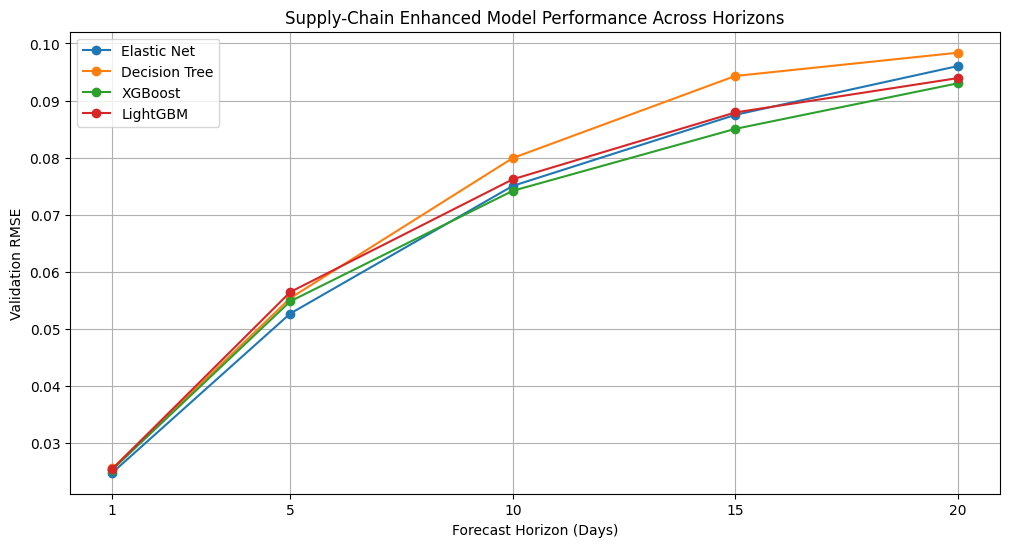

In [26]:
# ============================================================
# CELL 34 — MULTI-HORIZON RMSE COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

for model_name in enhanced_models.keys():

    model_data = horizon_results_df[
        horizon_results_df["Model"] == model_name
    ]

    plt.plot(
        model_data["Horizon"],
        model_data["RMSE"],
        marker="o",
        label=model_name
    )

plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("Validation RMSE")
plt.title(
    "Supply-Chain Enhanced Model Performance Across Horizons"
)

plt.xticks(HORIZONS)
plt.legend()
plt.grid(True)

plt.show()

In [27]:
# ============================================================
# CELL 35 — FINAL CONFIGURATION SELECTION
# ============================================================

# Find the single lowest validation RMSE
best_configuration = (
    horizon_results_df
    .loc[
        horizon_results_df["RMSE"].idxmin()
    ]
)

BEST_HORIZON = int(
    best_configuration["Horizon"]
)

BEST_MODEL_NAME = (
    best_configuration["Model"]
)

BEST_VALIDATION_RMSE = (
    best_configuration["RMSE"]
)

BEST_VALIDATION_MAE = (
    best_configuration["MAE"]
)

BEST_VALIDATION_R2 = (
    best_configuration["R2"]
)

print("=" * 70)
print("SELECTED FINAL CONFIGURATION")
print("=" * 70)

print(
    f"Model             : {BEST_MODEL_NAME}"
)

print(
    f"Forecast horizon  : {BEST_HORIZON} day(s)"
)

print(
    f"Validation RMSE   : {BEST_VALIDATION_RMSE:.6f}"
)

print(
    f"Validation MAE    : {BEST_VALIDATION_MAE:.6f}"
)

print(
    f"Validation R²     : {BEST_VALIDATION_R2:.6f}"
)

SELECTED FINAL CONFIGURATION
Model             : Elastic Net
Forecast horizon  : 1 day(s)
Validation RMSE   : 0.024832
Validation MAE    : 0.018036
Validation R²     : -0.041086


## 6. Final Out-of-Sample Evaluation

The best model and forecast horizon were selected using only the training
and validation periods.

The final model is now retrained using the combined training and
validation datasets.

The final test period remains completely unseen during model selection.

This provides an out-of-sample estimate of the model's predictive
performance.

In [28]:
# ============================================================
# CELL 37 — FINAL MODEL PREPARATION
# ============================================================

FINAL_TARGET = f"Target_{BEST_HORIZON}D"

y_sc_all = sc_full[FINAL_TARGET]

# Train + validation
X_final_train = pd.concat(
    [X_sc_train, X_sc_val]
)

y_final_train = pd.concat(
    [
        y_sc_all.iloc[:sc_train_end],
        y_sc_all.iloc[sc_train_end:sc_val_end]
    ]
)

# Final untouched test target
y_final_test = y_sc_all.iloc[
    sc_val_end:
].copy()

print("=" * 70)
print("FINAL MODEL DATA")
print("=" * 70)

print(
    f"Model              : {BEST_MODEL_NAME}"
)

print(
    f"Forecast horizon   : {BEST_HORIZON} day(s)"
)

print(
    f"Training samples   : {len(X_final_train)}"
)

print(
    f"Final test samples : {len(X_sc_test)}"
)

print(
    f"Final target       : {FINAL_TARGET}"
)

FINAL MODEL DATA
Model              : Elastic Net
Forecast horizon   : 1 day(s)
Training samples   : 2207
Final test samples : 552
Final target       : Target_1D


In [29]:
# ============================================================
# CELL 38 — TRAIN FINAL MODEL AND PREDICT
# ============================================================

# Create a fresh copy of the selected model
selected_template = enhanced_models[
    BEST_MODEL_NAME
]

final_model = selected_template.__class__(
    **selected_template.get_params()
)

# Elastic Net requires standardization
if BEST_MODEL_NAME == "Elastic Net":

    final_scaler = StandardScaler()

    X_final_train_model = (
        final_scaler.fit_transform(
            X_final_train
        )
    )

    X_final_test_model = (
        final_scaler.transform(
            X_sc_test
        )
    )

else:

    X_final_train_model = X_final_train
    X_final_test_model = X_sc_test

# Train
final_model.fit(
    X_final_train_model,
    y_final_train
)

# Predict completely unseen test period
final_predictions = final_model.predict(
    X_final_test_model
)

print("Final model trained successfully.")

print(
    f"Predictions generated: "
    f"{len(final_predictions)}"
)

Final model trained successfully.
Predictions generated: 552


In [30]:
# ============================================================
# CELL 39 — FINAL REGRESSION PERFORMANCE
# ============================================================

final_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        final_predictions
    )
)

final_mae = mean_absolute_error(
    y_final_test,
    final_predictions
)

final_r2 = r2_score(
    y_final_test,
    final_predictions
)

print("=" * 70)
print("FINAL UNSEEN TEST PERFORMANCE")
print("=" * 70)

print(
    f"RMSE : {final_rmse:.6f}"
)

print(
    f"MAE  : {final_mae:.6f}"
)

print(
    f"R²   : {final_r2:.6f}"
)

FINAL UNSEEN TEST PERFORMANCE
RMSE : 0.017954
MAE  : 0.013506
R²   : -0.013369


## 7. Quantitative Trading Strategy

The regression predictions are converted into trading positions.

For the selected 1-day forecasting configuration:

- Positive predicted return → Long position
- Negative predicted return → Short position

A prediction threshold is selected using the validation period only.

The final test period is not used to select the threshold.

A transaction cost of 0.1% is applied whenever the position changes.

This prevents the final performance estimate from benefiting from
information from the future test period.

In [31]:
# ============================================================
# CELL 41 — VALIDATION THRESHOLD SELECTION
# ============================================================

# We only use this section for a 1-day trading strategy.
# If the selected horizon is not 1 day, trading is skipped because
# overlapping multi-day return targets require a different holding
# period implementation.

if BEST_HORIZON == 1:

    # Train selected model ONLY on training data
    validation_model = selected_template.__class__(
        **selected_template.get_params()
    )

    if BEST_MODEL_NAME == "Elastic Net":

        validation_scaler = StandardScaler()

        X_train_for_validation = (
            validation_scaler.fit_transform(
                X_sc_train
            )
        )

        X_val_for_validation = (
            validation_scaler.transform(
                X_sc_val
            )
        )

    else:

        X_train_for_validation = X_sc_train
        X_val_for_validation = X_sc_val

    validation_model.fit(
        X_train_for_validation,
        y_sc_train
    )

    validation_predictions = (
        validation_model.predict(
            X_val_for_validation
        )
    )

    validation_actual = (
        y_sc_val.values
    )

    # Thresholds are selected BEFORE seeing final test results.
    thresholds = [
        0.0,
        0.00025,
        0.0005,
        0.00075,
        0.001,
        0.0015,
        0.002,
        0.0025
    ]

    threshold_results = []

    for threshold in thresholds:

        signals = np.where(
            validation_predictions > threshold,
            1,
            np.where(
                validation_predictions < -threshold,
                -1,
                0
            )
        )

        strategy_returns = (
            signals *
            validation_actual
        )

        equity = np.cumprod(
            1 + strategy_returns
        )

        total_return = (
            equity[-1] - 1
        )

        annualized_volatility = (
            np.std(
                strategy_returns,
                ddof=1
            )
            * np.sqrt(252)
        )

        annualized_return = (
            (1 + total_return)
            ** (252 / len(strategy_returns))
            - 1
        )

        if annualized_volatility > 0:
            sharpe = (
                annualized_return /
                annualized_volatility
            )
        else:
            sharpe = 0

        active_days = np.sum(
            signals != 0
        )

        threshold_results.append({
            "Threshold": threshold,
            "Total Return": total_return,
            "Annualized Return": annualized_return,
            "Volatility": annualized_volatility,
            "Sharpe": sharpe,
            "Active Days": active_days
        })

    threshold_df = pd.DataFrame(
        threshold_results
    )

    display(threshold_df)

    # Require a minimum amount of trading activity
    eligible_thresholds = threshold_df[
        threshold_df["Active Days"] >= 50
    ]

    if len(eligible_thresholds) > 0:

        selected_threshold = (
            eligible_thresholds.loc[
                eligible_thresholds["Sharpe"].idxmax(),
                "Threshold"
            ]
        )

    else:

        selected_threshold = 0.0

    print(
        f"\nSelected validation threshold: "
        f"{selected_threshold:.5f}"
    )

else:

    selected_threshold = None

    print(
        "Trading strategy not activated because "
        f"the selected horizon is {BEST_HORIZON} days."
    )

,Threshold,Total Return,Annualized Return,Volatility,Sharpe,Active Days
0,0.00000,-0.549190,-0.304911,0.386605,-0.788689,552
1,0.00025,-0.565090,-0.316212,0.381342,-0.829208,523
2,0.00050,-0.473554,-0.253909,0.374125,-0.678674,492
3,0.00075,-0.436523,-0.230392,0.368983,-0.624397,467
4,0.00100,-0.364048,-0.186685,0.347521,-0.537190,433
5,0.00150,-0.398340,-0.207008,0.330936,-0.625522,384
6,0.00200,-0.183967,-0.088635,0.310138,-0.285791,340
7,0.00250,-0.137030,-0.065067,0.278912,-0.233287,294



Selected validation threshold: 0.00250


In [32]:
# ============================================================
# CELL 42 — FINAL OUT-OF-SAMPLE TRADING STRATEGY
# ============================================================

if BEST_HORIZON == 1:

    final_actual_returns = (
        y_final_test.values
    )

    # Long / Short / Neutral
    final_signals = np.where(
        final_predictions > selected_threshold,
        1,
        np.where(
            final_predictions < -selected_threshold,
            -1,
            0
        )
    )

    # Gross strategy returns
    gross_strategy_returns = (
        final_signals *
        final_actual_returns
    )

    # Transaction cost
    TRANSACTION_COST = 0.001

    position_change = np.abs(
        np.diff(
            np.concatenate(
                [[0], final_signals]
            )
        )
    )

    transaction_costs = (
        position_change *
        TRANSACTION_COST
    )

    # Net returns
    net_strategy_returns = (
        gross_strategy_returns -
        transaction_costs
    )

    print("=" * 70)
    print("FINAL OUT-OF-SAMPLE TRADING STRATEGY")
    print("=" * 70)

    print(
        f"Threshold       : {selected_threshold:.5f}"
    )

    print(
        f"Transaction cost: "
        f"{TRANSACTION_COST * 100:.2f}%"
    )

    print(
        f"Long days       : "
        f"{np.sum(final_signals == 1)}"
    )

    print(
        f"Short days      : "
        f"{np.sum(final_signals == -1)}"
    )

    print(
        f"Neutral days    : "
        f"{np.sum(final_signals == 0)}"
    )

else:

    net_strategy_returns = None

    print(
        "No daily trading strategy generated."
    )

FINAL OUT-OF-SAMPLE TRADING STRATEGY
Threshold       : 0.00250
Transaction cost: 0.10%
Long days       : 95
Short days      : 95
Neutral days    : 362


In [33]:
# ============================================================
# CELL 43 — STRATEGY PERFORMANCE METRICS
# ============================================================

def calculate_performance(returns):

    returns = np.asarray(returns)

    returns = returns[
        ~np.isnan(returns)
    ]

    equity = np.cumprod(
        1 + returns
    )

    total_return = (
        equity[-1] - 1
    )

    annualized_return = (
        (1 + total_return)
        ** (252 / len(returns))
        - 1
    )

    annualized_volatility = (
        np.std(
            returns,
            ddof=1
        )
        * np.sqrt(252)
    )

    if annualized_volatility > 0:

        sharpe = (
            annualized_return /
            annualized_volatility
        )

    else:

        sharpe = 0

    running_max = np.maximum.accumulate(
        equity
    )

    drawdown = (
        equity /
        running_max
        - 1
    )

    max_drawdown = drawdown.min()

    win_rate = np.mean(
        returns > 0
    )

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown": max_drawdown,
        "Win Rate": win_rate
    }


if net_strategy_returns is not None:

    strategy_metrics = calculate_performance(
        net_strategy_returns
    )

    print("=" * 70)
    print("ML TRADING STRATEGY PERFORMANCE")
    print("=" * 70)

    for metric, value in strategy_metrics.items():

        print(
            f"{metric:25s}: {value:.4f}"
        )

ML TRADING STRATEGY PERFORMANCE
Total Return             : -0.1966
Annualized Return        : -0.0951
Annualized Volatility    : 0.1594
Sharpe Ratio             : -0.5967
Maximum Drawdown         : -0.2419
Win Rate                 : 0.1757


## 8. Buy & Hold Benchmark

To determine whether the machine learning strategy provides value, it is
compared with a simple VWAGY Buy & Hold strategy over exactly the same
final test period.

The benchmark assumes that the investor continuously holds VWAGY.

The comparison uses:

- Total return
- Annualized return
- Annualized volatility
- Sharpe ratio
- Maximum drawdown
- Win rate

In [34]:
# ============================================================
# CELL 45 — VWAGY BUY & HOLD BENCHMARK
# ============================================================

# Use the original VWAGY price series.
# Align it to the final enhanced-model test period.

final_test_dates = X_sc_test.index

vw_test_prices = vw_data[
    "Close"
].reindex(
    final_test_dates
)

# Daily Buy & Hold returns
buy_hold_returns = (
    vw_test_prices
    .pct_change()
    .fillna(0)
)

buy_hold_metrics = calculate_performance(
    buy_hold_returns.values
)

print("=" * 70)
print("VWAGY BUY & HOLD PERFORMANCE")
print("=" * 70)

for metric, value in buy_hold_metrics.items():

    print(
        f"{metric:25s}: {value:.4f}"
    )

VWAGY BUY & HOLD PERFORMANCE
Total Return             : 0.0184
Annualized Return        : 0.0084
Annualized Volatility    : 0.2831
Sharpe Ratio             : 0.0296
Maximum Drawdown         : -0.4286
Win Rate                 : 0.4674


In [35]:
# ============================================================
# CELL 46 — FINAL STRATEGY COMPARISON
# ============================================================

if net_strategy_returns is not None:

    final_comparison = pd.DataFrame({

        "ML Strategy": strategy_metrics,

        "VWAGY Buy & Hold": buy_hold_metrics

    }).T

    display(
        final_comparison
    )

else:

    print(
        "No trading strategy available "
        "for the selected forecast horizon."
    )

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Win Rate
ML Strategy,-0.196643,-0.095125,0.159426,-0.596671,-0.241930,0.175725
VWAGY Buy & Hold,0.018426,0.008370,0.283130,0.029564,-0.428625,0.467391


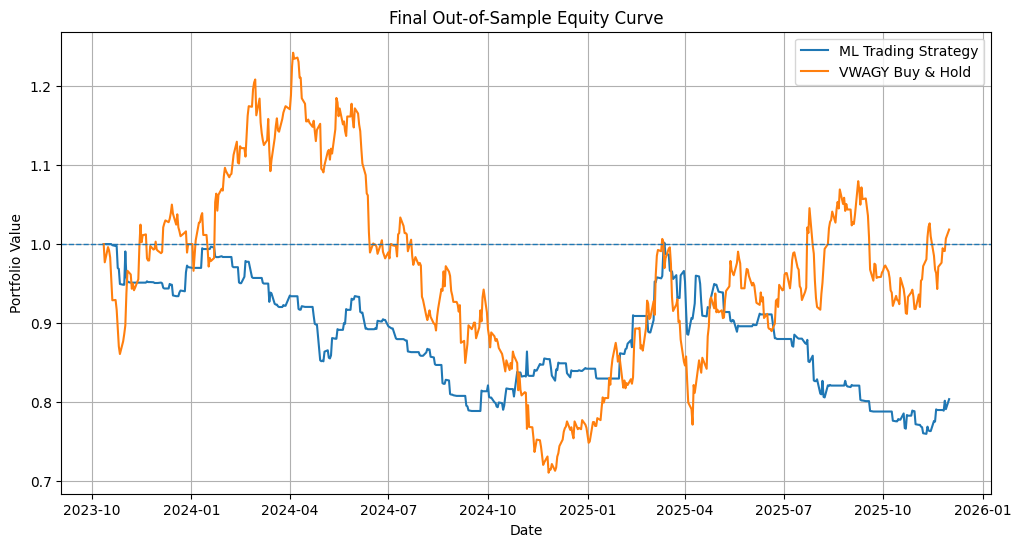

In [36]:
# ============================================================
# CELL 47 — EQUITY CURVE COMPARISON
# ============================================================

if net_strategy_returns is not None:

    ml_equity = np.cumprod(
        1 + net_strategy_returns
    )

    buy_hold_equity = np.cumprod(
        1 + buy_hold_returns.values
    )

    plt.figure(
        figsize=(12, 6)
    )

    plt.plot(
        final_test_dates,
        ml_equity,
        label="ML Trading Strategy"
    )

    plt.plot(
        final_test_dates,
        buy_hold_equity,
        label="VWAGY Buy & Hold"
    )

    plt.axhline(
        1,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        "Final Out-of-Sample Equity Curve"
    )

    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid(True)

    plt.show()

,Feature,Importance
4,APTV_Return_Lag_5,0.000884
0,APTV_Return_Lag_1,0.000835
34,BWA_Return_Lag_7,0.000799
153,BAS.DE_Return_Lag_14,0.000772
168,IFX.DE_Return_Lag_1,0.000592
167,BAS.DE_Return_Lag_28,0.000588
247,HLE.DE_Return_Lag_24,0.000579
62,TSM_Return_Lag_7,0.000543
128,LEA_Return_Lag_17,0.000515
89,MGA_Return_Lag_6,0.000510


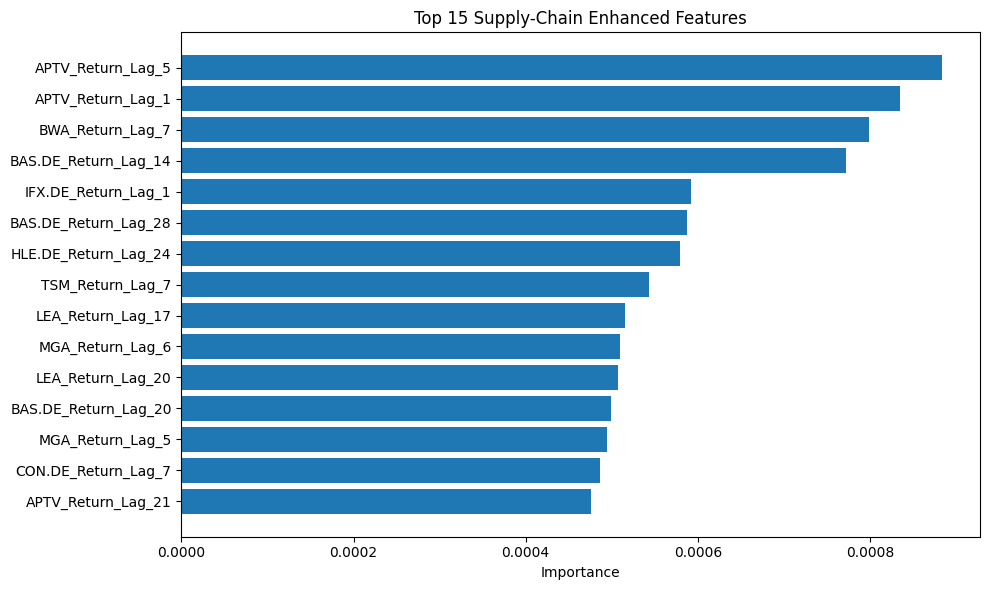

In [37]:
# ============================================================
# CELL 48 — FEATURE IMPORTANCE / COEFFICIENT ANALYSIS
# ============================================================

if BEST_MODEL_NAME == "Elastic Net":

    importance_values = np.abs(
        final_model.coef_
    )

else:

    importance_values = (
        final_model.feature_importances_
    )

feature_importance = pd.DataFrame({
    "Feature": SC_FEATURE_COLUMNS,
    "Importance": importance_values
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

display(
    feature_importance
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.title(
    "Top 15 Supply-Chain Enhanced Features"
)

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [38]:
# ============================================================
# CELL 49 — FINAL PROJECT SUMMARY
# ============================================================

print("=" * 75)
print("FINAL PROJECT SUMMARY")
print("=" * 75)

print(
    f"\nBaseline best model: "
    f"{baseline_best_model}"
)

print(
    f"Enhanced best model: "
    f"{BEST_MODEL_NAME}"
)

print(
    f"Enhanced forecast horizon: "
    f"{BEST_HORIZON} day(s)"
)

print(
    f"\nEnhanced validation RMSE: "
    f"{BEST_VALIDATION_RMSE:.6f}"
)

print(
    f"Enhanced final test RMSE: "
    f"{final_rmse:.6f}"
)

print(
    f"Enhanced final test MAE: "
    f"{final_mae:.6f}"
)

print(
    f"Enhanced final test R²: "
    f"{final_r2:.6f}"
)

if net_strategy_returns is not None:

    print(
        f"\nML strategy total return: "
        f"{strategy_metrics['Total Return']:.2%}"
    )

    print(
        f"ML strategy Sharpe: "
        f"{strategy_metrics['Sharpe Ratio']:.3f}"
    )

    print(
        f"ML strategy max drawdown: "
        f"{strategy_metrics['Maximum Drawdown']:.2%}"
    )

print(
    f"\nVWAGY Buy & Hold total return: "
    f"{buy_hold_metrics['Total Return']:.2%}"
)

print(
    f"VWAGY Buy & Hold Sharpe: "
    f"{buy_hold_metrics['Sharpe Ratio']:.3f}"
)

print(
    f"VWAGY Buy & Hold max drawdown: "
    f"{buy_hold_metrics['Maximum Drawdown']:.2%}"
)

FINAL PROJECT SUMMARY

Baseline best model: Elastic Net
Enhanced best model: Elastic Net
Enhanced forecast horizon: 1 day(s)

Enhanced validation RMSE: 0.024832
Enhanced final test RMSE: 0.017954
Enhanced final test MAE: 0.013506
Enhanced final test R²: -0.013369

ML strategy total return: -19.66%
ML strategy Sharpe: -0.597
ML strategy max drawdown: -24.19%

VWAGY Buy & Hold total return: 1.84%
VWAGY Buy & Hold Sharpe: 0.030
VWAGY Buy & Hold max drawdown: -42.86%


## 9. Conclusions

This project evaluated machine learning approaches for predicting
VWAGY returns and constructing a quantitative trading strategy.

The baseline experiment used Volkswagen's own historical market
information, including returns, moving-average relationships,
volatility, and volume indicators.

A second experiment extended the feature space using lagged returns from
selected supply-chain proxy companies. This was implemented as a
scaled-down adaptation of the reference supply-chain methodology.

Four machine learning algorithms were evaluated:

- Elastic Net
- Decision Tree
- XGBoost
- LightGBM

The models were evaluated using chronological training, validation, and
final test periods to prevent temporal data leakage.

The final model and forecast horizon were selected using validation data.
The final test period was then used only for out-of-sample evaluation.

The trading strategy was compared with a VWAGY Buy & Hold benchmark using
return, volatility, Sharpe ratio, maximum drawdown, and win rate.

The results should be interpreted as an empirical evaluation rather than
evidence that stock returns can be reliably predicted. In particular,
negative or near-zero R² values indicate that next-day return prediction
remains difficult.

The supply-chain experiment demonstrates how information from related
companies can be incorporated into a machine learning feature set, while
also highlighting the limitations of a small proxy universe and the
absence of proprietary macroeconomic data used in the reference study.

Overall, the project demonstrates an end-to-end quantitative trading
pipeline covering data collection, feature engineering, chronological
model validation, machine learning, out-of-sample testing, and trading
strategy evaluation.